In [3]:
#IRIS WITH LIB
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
data = pd.read_csv("iris.csv")

# Features and target
X = data.drop("species", axis=1)
y = data["species"]

# Train test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Choose K value
k = 5

# Build model
model = KNeighborsClassifier(n_neighbors=k)

# Train model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [4]:
#IRIS WITHOUT LIB
import pandas as pd
import numpy as np
from collections import Counter
from math import sqrt

# Load dataset
data = pd.read_csv("iris.csv")

# Convert species to numeric
data['species'] = data['species'].astype('category').cat.codes

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Train-test split (80/20)
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# Euclidean distance
def distance(a, b):
    return sqrt(np.sum((a - b) ** 2))

# KNN function
def knn_predict(X_train, y_train, test_point, k=5):

    distances = []

    for i in range(len(X_train)):
        d = distance(test_point, X_train[i])
        distances.append((d, y_train[i]))

    distances.sort()

    neighbors = distances[:k]

    labels = [label for _, label in neighbors]

    return Counter(labels).most_common(1)[0][0]

# Predictions
predictions = []

for test_point in X_test:
    pred = knn_predict(X_train, y_train, test_point, k=5)
    predictions.append(pred)

# Accuracy
accuracy = np.sum(predictions == y_test) / len(y_test)

print("Accuracy:", accuracy)

Accuracy: 0.8


In [5]:
#DIABETES WITH LIB
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
data = pd.read_csv("diabetes.csv")

# Features and target
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

# Choose K
k = 7

# Model
model = KNeighborsClassifier(n_neighbors=k)

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.6818181818181818
Confusion Matrix:
 [[78 21]
 [28 27]]


In [6]:
#DIABETES WITHOUT LIB
import pandas as pd
import numpy as np
from math import sqrt
from collections import Counter

# Load dataset
data = pd.read_csv("diabetes.csv")

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Feature scaling (manual standardization)
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)

X = (X - mean) / std

# Train-test split
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# Distance function
def distance(a, b):
    return sqrt(np.sum((a - b) ** 2))

# KNN function
def knn_predict(X_train, y_train, test_point, k=7):

    distances = []

    for i in range(len(X_train)):
        d = distance(test_point, X_train[i])
        distances.append((d, y_train[i]))

    distances.sort()

    neighbors = distances[:k]

    labels = [label for _, label in neighbors]

    return Counter(labels).most_common(1)[0][0]

# Predictions
predictions = []

for test_point in X_test:
    pred = knn_predict(X_train, y_train, test_point, k=7)
    predictions.append(pred)

# Accuracy
accuracy = np.sum(predictions == y_test) / len(y_test)

print("Accuracy:", accuracy)

Accuracy: 0.7272727272727273


Best K value: 6
Accuracy: 0.9344262295081968
Confusion Matrix:
 [[28  1]
 [ 3 29]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.97      0.93        29
           1       0.97      0.91      0.94        32

    accuracy                           0.93        61
   macro avg       0.93      0.94      0.93        61
weighted avg       0.94      0.93      0.93        61



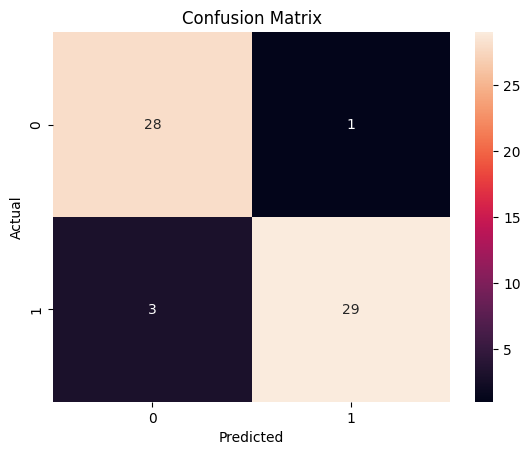

In [7]:
#Heart with Lib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

# Load dataset
data = pd.read_csv("heart.csv")

# Features and target
X = data.drop("target", axis=1)
y = data["target"]

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

# Try different K values
scores = []

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    scores.append(accuracy_score(y_test, pred))

# Best K
best_k = scores.index(max(scores)) + 1
print("Best K value:", best_k)

# Train final model
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

# Plot Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [8]:
#Heart Without Lib
import pandas as pd
import numpy as np
from math import sqrt
from collections import Counter

# Load dataset
data = pd.read_csv("heart.csv")

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Feature scaling (manual standardization)
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)
X = (X - mean) / std

# Train-test split
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# Distance function
def distance(a, b):
    return sqrt(np.sum((a - b) ** 2))

# KNN function
def knn_predict(X_train, y_train, test_point, k):

    distances = []

    for i in range(len(X_train)):
        d = distance(test_point, X_train[i])
        distances.append((d, y_train[i]))

    distances.sort()

    neighbors = distances[:k]

    labels = [label for _, label in neighbors]

    return Counter(labels).most_common(1)[0][0]

# Try different K values
best_k = 1
best_acc = 0

for k in range(1, 21):

    predictions = []

    for test_point in X_test:
        pred = knn_predict(X_train, y_train, test_point, k)
        predictions.append(pred)

    acc = np.sum(predictions == y_test) / len(y_test)

    if acc > best_acc:
        best_acc = acc
        best_k = k

print("Best K:", best_k)
print("Best Accuracy:", best_acc)

Best K: 3
Best Accuracy: 0.6229508196721312
